# **EDA on piezometer data**

In [233]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [234]:
# Loading the dataframe
input_path = Path("..") / 'data' / 'raw' / 'piezometer_raw.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the piezometer dataframe:\n", df.shape)

,code_bss,bss_id,urn_bss,date_mesure,timestamp_mesure,niveau_nappe_eau,mode_obtention,statut,qualification,code_continuite,nom_continuite,code_producteur,nom_producteur,code_nature_mesure,nom_nature_mesure,profondeur_nappe
0,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-14,955670400000,102.31,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.85
1,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-15,955756800000,102.29,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.87
2,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-16,955843200000,102.28,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.88
3,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-17,955929600000,102.29,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.87
4,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-18,956016000000,102.31,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.85


Shape of the piezometer dataframe:
 (8851, 16)


8851 rows and 17 columns

In [235]:
df.describe()

,timestamp_mesure,niveau_nappe_eau,code_continuite,code_producteur,profondeur_nappe
count,8.851000e+03,8851.000000,8851.000000,8.851000e+03,8851.000000
mean,1.379904e+12,103.236502,1.997062,1.171034e+13,3.923498
std,2.414339e+11,0.978735,0.054122,9.854149e+12,0.978735
min,9.556704e+11,100.060000,1.000000,2.310000e+02,2.210000
25%,1.159186e+12,102.560000,2.000000,2.310000e+02,3.120000
50%,1.392075e+12,103.450000,2.000000,2.000158e+13,3.710000
75%,1.587010e+12,104.040000,2.000000,2.000158e+13,4.600000
max,1.784419e+12,104.950000,2.000000,2.000158e+13,7.100000


In [236]:
df["date_mesure"] = pd.to_datetime(df["date_mesure"])
df["date_mesure"].describe()

count                          8851
mean     2013-09-22 21:43:30.010168
min             2000-04-14 00:00:00
25%             2006-09-25 12:00:00
50%             2014-02-10 00:00:00
75%             2020-04-15 12:00:00
max             2026-07-19 00:00:00
Name: date_mesure, dtype: object

In [237]:
df.columns.tolist()

['code_bss',
 'bss_id',
 'urn_bss',
 'date_mesure',
 'timestamp_mesure',
 'niveau_nappe_eau',
 'mode_obtention',
 'statut',
 'qualification',
 'code_continuite',
 'nom_continuite',
 'code_producteur',
 'nom_producteur',
 'code_nature_mesure',
 'nom_nature_mesure',
 'profondeur_nappe']

In [238]:
df.value_counts()

code_bss         bss_id      urn_bss                                                     date_mesure  timestamp_mesure  niveau_nappe_eau  mode_obtention  statut                     qualification  code_continuite  nom_continuite                code_producteur  nom_producteur                                                                                                        code_nature_mesure  nom_nature_mesure  profondeur_nappe
10906X0039/C2-1  BSS002MNYD  http://services.ades.eaufrance.fr/pointeau/10906X0039/C2-1  2004-02-17   1076976000000     103.70            Valeur mesurée  Donnée contrôlée niveau 1  Correcte       2                Point lié au point précédent  231              Bureau de Recherches Géologiques et Minières (231)                                                                    N                   Naturel            3.46                1
                                                                                         2004-02-18   1077062400000     103.69 

In [239]:
df['mode_obtention'].value_counts()

mode_obtention
Valeur mesurée         7629
Valeur reconstituée    1222
Name: count, dtype: int64

In [240]:
df['date_mesure']

0      2000-04-14
1      2000-04-15
2      2000-04-16
3      2000-04-17
4      2000-04-18
          ...    
8846   2026-07-15
8847   2026-07-16
8848   2026-07-17
8849   2026-07-18
8850   2026-07-19
Name: date_mesure, Length: 8851, dtype: datetime64[us]

In [241]:
# Evaluation of the datatype per columns
df.dtypes

code_bss                         str
bss_id                           str
urn_bss                          str
date_mesure           datetime64[us]
timestamp_mesure               int64
niveau_nappe_eau             float64
mode_obtention                   str
statut                           str
qualification                    str
code_continuite                int64
nom_continuite                   str
code_producteur                int64
nom_producteur                   str
code_nature_mesure               str
nom_nature_mesure                str
profondeur_nappe             float64
dtype: object

In [242]:
# Number and percentage of NaN
print("Number of NaN per columns:\n", df.isnull().sum())
percent_nan = (df.isnull().sum() / df.shape[0]) / 100
print("\nPercentage of NaN per columns:\n", round(percent_nan, 4))

Number of NaN per columns:
 code_bss                 0
bss_id                   0
urn_bss                  0
date_mesure              0
timestamp_mesure         0
niveau_nappe_eau         0
mode_obtention           0
statut                   0
qualification            0
code_continuite          0
nom_continuite           0
code_producteur          0
nom_producteur           0
code_nature_mesure    1439
nom_nature_mesure     1439
profondeur_nappe         0
dtype: int64

Percentage of NaN per columns:
 code_bss              0.0000
bss_id                0.0000
urn_bss               0.0000
date_mesure           0.0000
timestamp_mesure      0.0000
niveau_nappe_eau      0.0000
mode_obtention        0.0000
statut                0.0000
qualification         0.0000
code_continuite       0.0000
nom_continuite        0.0000
code_producteur       0.0000
nom_producteur        0.0000
code_nature_mesure    0.0016
nom_nature_mesure     0.0016
profondeur_nappe      0.0000
dtype: float64


## Investigation of the columns code_nature_mesure & nom_nature_mesure
As there is 1439 NaN on those columns, we will look at the type of data in it

In [243]:
print(df[['code_nature_mesure', 'nom_nature_mesure']].value_counts())

code_nature_mesure  nom_nature_mesure
N                   Naturel              7412
Name: count, dtype: int64


In [244]:
# Regarding the contains of those two columns (useless), they will be dropped. 
columns_to_drop = ['code_nature_mesure', 'nom_nature_mesure', 'urn_bss', 'timestamp_mesure', 
                   'statut', 'qualification', 'code_continuite', 'nom_continuite', 'code_producteur']

print("Shape of the dataframe before dropping columns:", df.shape)
df_drop = df.drop(columns=columns_to_drop)
print("\nShape of the dataframe after dropping columns:", df_drop.shape)

Shape of the dataframe before dropping columns: (8851, 16)

Shape of the dataframe after dropping columns: (8851, 7)


In [245]:
df_drop.isnull().sum()

code_bss            0
bss_id              0
date_mesure         0
niveau_nappe_eau    0
mode_obtention      0
nom_producteur      0
profondeur_nappe    0
dtype: int64

In [246]:
df_drop.rename(columns={'date_mesure': 'date_index'})

,code_bss,bss_id,date_index,niveau_nappe_eau,mode_obtention,nom_producteur,profondeur_nappe
0,10906X0039/C2-1,BSS002MNYD,2000-04-14,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85
1,10906X0039/C2-1,BSS002MNYD,2000-04-15,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
2,10906X0039/C2-1,BSS002MNYD,2000-04-16,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.88
3,10906X0039/C2-1,BSS002MNYD,2000-04-17,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
4,10906X0039/C2-1,BSS002MNYD,2000-04-18,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85
...,...,...,...,...,...,...,...
8846,10906X0039/C2-1,BSS002MNYD,2026-07-15,103.85,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.31
8847,10906X0039/C2-1,BSS002MNYD,2026-07-16,103.84,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.32
8848,10906X0039/C2-1,BSS002MNYD,2026-07-17,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.30
8849,10906X0039/C2-1,BSS002MNYD,2026-07-18,103.87,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.29


In [247]:
display(df_drop.head(5))

,code_bss,bss_id,date_mesure,niveau_nappe_eau,mode_obtention,nom_producteur,profondeur_nappe
0,10906X0039/C2-1,BSS002MNYD,2000-04-14,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85
1,10906X0039/C2-1,BSS002MNYD,2000-04-15,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
2,10906X0039/C2-1,BSS002MNYD,2000-04-16,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.88
3,10906X0039/C2-1,BSS002MNYD,2000-04-17,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
4,10906X0039/C2-1,BSS002MNYD,2000-04-18,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85


In [248]:
print(df_drop['nom_producteur'].value_counts())

nom_producteur
Syndicat Mixte pour la Protection et la Gestion des Nappes Souterraines de la Plaine du Roussillon  (20001584000016)    5182
Bureau de Recherches Géologiques et Minières (231)                                                                      3669
Name: count, dtype: int64


In [249]:
df_drop.describe()

,date_mesure,niveau_nappe_eau,profondeur_nappe
count,8851,8851.000000,8851.000000
mean,2013-09-22 21:43:30.010168,103.236502,3.923498
min,2000-04-14 00:00:00,100.060000,2.210000
25%,2006-09-25 12:00:00,102.560000,3.120000
50%,2014-02-10 00:00:00,103.450000,3.710000
75%,2020-04-15 12:00:00,104.040000,4.600000
max,2026-07-19 00:00:00,104.950000,7.100000
std,NaN,0.978735,0.978735


# Visulization of the 'niveau_nappe_eau' against 'prodondeur_nappe'

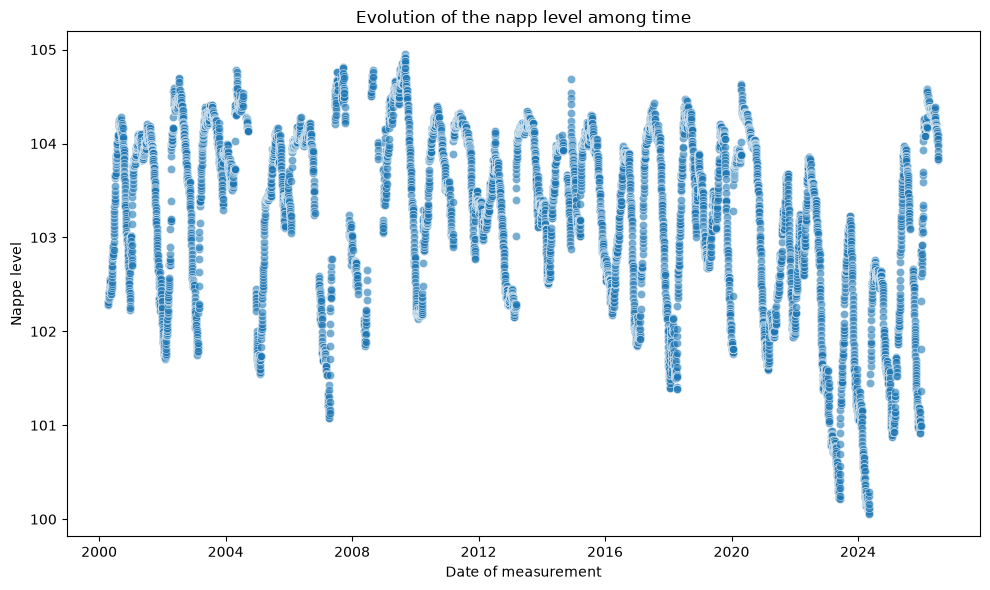

In [250]:
x = df_drop["date_mesure"]
y = df_drop["niveau_nappe_eau"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.6, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Date of measurement")
ax.set_ylabel("Nappe level")
ax.set_title("Evolution of the napp level among time")

plt.tight_layout()
plt.show()

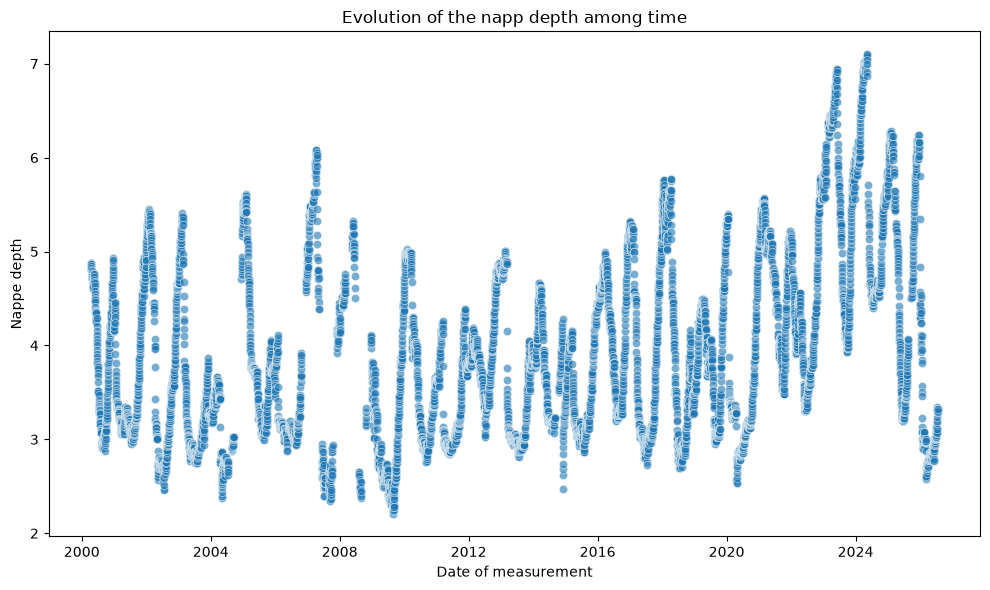

In [251]:
x = df_drop["date_mesure"]
y = df_drop["profondeur_nappe"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.6, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Date of measurement")
ax.set_ylabel("Nappe depth")
ax.set_title("Evolution of the napp depth among time")

plt.tight_layout()
plt.show()

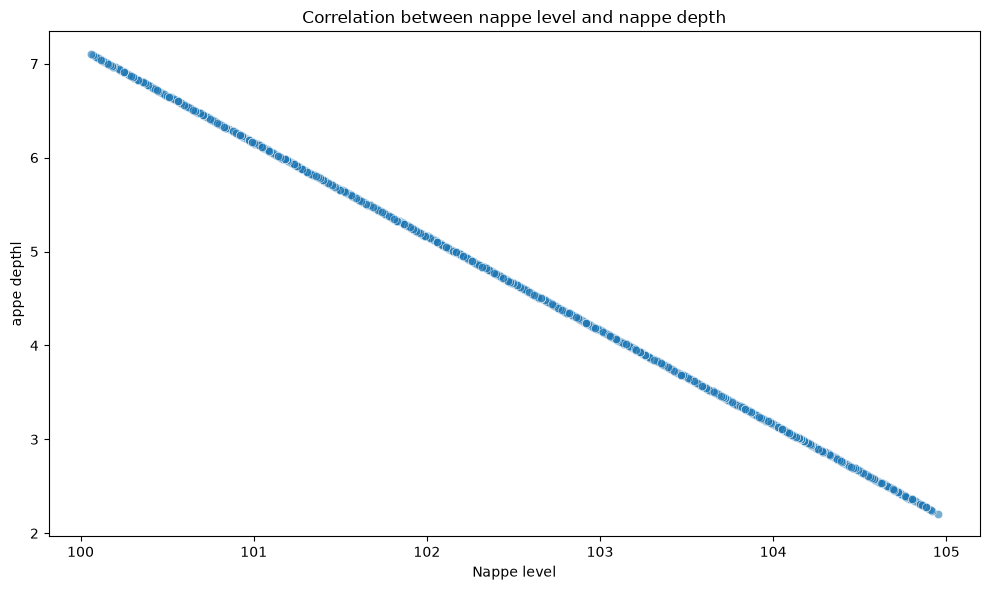

In [252]:
x = df_drop["niveau_nappe_eau"]
y = df_drop["profondeur_nappe"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.6, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Nappe level")
ax.set_ylabel("appe depthl")
ax.set_title("Correlation between nappe level and nappe depth")

plt.tight_layout()
plt.show()

In [253]:
df_drop[["niveau_nappe_eau", "profondeur_nappe"]].corr()

,niveau_nappe_eau,profondeur_nappe
niveau_nappe_eau,1.0,-1.0
profondeur_nappe,-1.0,1.0


Because 'niveau_nappe_eau' and 'profondeur_nappe' are fully correlated, we took the decision to drop the nappe depth.

In [254]:
df_drop = df_drop.drop(columns=['profondeur_nappe'])

# Final checkup of the dataframe before export

In [255]:
print("Number of NaN per columns:\n", df_drop.isnull().sum())
print

Number of NaN per columns:
 code_bss            0
bss_id              0
date_mesure         0
niveau_nappe_eau    0
mode_obtention      0
nom_producteur      0
dtype: int64


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [256]:
display(df_drop)

,code_bss,bss_id,date_mesure,niveau_nappe_eau,mode_obtention,nom_producteur
0,10906X0039/C2-1,BSS002MNYD,2000-04-14,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
1,10906X0039/C2-1,BSS002MNYD,2000-04-15,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
2,10906X0039/C2-1,BSS002MNYD,2000-04-16,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
3,10906X0039/C2-1,BSS002MNYD,2000-04-17,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
4,10906X0039/C2-1,BSS002MNYD,2000-04-18,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
...,...,...,...,...,...,...
8846,10906X0039/C2-1,BSS002MNYD,2026-07-15,103.85,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
8847,10906X0039/C2-1,BSS002MNYD,2026-07-16,103.84,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
8848,10906X0039/C2-1,BSS002MNYD,2026-07-17,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
8849,10906X0039/C2-1,BSS002MNYD,2026-07-18,103.87,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...


# Saving the cleaned dataframe into .\data\raw

In [257]:
output_path = Path('..') / 'data' / 'interim' / 'piezometer_cleaned.csv'

df_drop.to_csv(output_path)

# **TO DELETE**

In [258]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np

In [259]:
# Loading the dataframe
input_path = Path("..") / 'data' / 'raw' / 'piezometer_raw.csv'
df_piezo = pd.read_csv(input_path)
display(df_piezo.head(5))
print("Shape of the piezometer dataframe:\n", df_piezo.shape)

,code_bss,bss_id,urn_bss,date_mesure,timestamp_mesure,niveau_nappe_eau,mode_obtention,statut,qualification,code_continuite,nom_continuite,code_producteur,nom_producteur,code_nature_mesure,nom_nature_mesure,profondeur_nappe
0,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-14,955670400000,102.31,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.85
1,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-15,955756800000,102.29,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.87
2,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-16,955843200000,102.28,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.88
3,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-17,955929600000,102.29,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.87
4,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-18,956016000000,102.31,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.85


Shape of the piezometer dataframe:
 (8851, 16)


In [260]:
def piezometer_dataset_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    """
    Objectives of this function is to clean the piezometer dataset before merging with 
    weather dataset and EDA.
    """
    df = pd.DataFrame(df)
    df = df.copy()
    
    # Setting 'date_index' as index of the dataframe
    df["date_index"] = pd.to_datetime(df["date_mesure"])  
    df = df.set_index("date_index")
    df.index = pd.to_datetime(df.index)
    
    # Dropping columns
    columns_to_drop = ['code_nature_mesure', 'nom_nature_mesure',  'urn_bss', 
                       'timestamp_mesure', 'statut', 'qualification', 'code_continuite', 
                       'nom_continuite', 'code_producteur', 'profondeur_nappe', 'date_mesure', 'Unnamed: 0']
    
    df = df.drop(columns=columns_to_drop, errors='ignore')
    
    # Changing the name of the column date (preparation for future merging)
    df = df.rename(columns={'date_mesure': 'date_index'})

    return df

In [261]:
df_piezo_cleaned = piezometer_dataset_cleaning(df_piezo)

In [262]:
df_piezo_cleaned

,code_bss,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur
date_index,,,,,
2000-04-14,10906X0039/C2-1,BSS002MNYD,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
2000-04-15,10906X0039/C2-1,BSS002MNYD,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
2000-04-16,10906X0039/C2-1,BSS002MNYD,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
2000-04-17,10906X0039/C2-1,BSS002MNYD,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
2000-04-18,10906X0039/C2-1,BSS002MNYD,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
...,...,...,...,...,...
2026-07-15,10906X0039/C2-1,BSS002MNYD,103.85,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
2026-07-16,10906X0039/C2-1,BSS002MNYD,103.84,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
2026-07-17,10906X0039/C2-1,BSS002MNYD,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...


In [263]:
# Loading the dataframe
input_path = Path("..") / 'data' / 'raw' / 'weather_raw.csv'
df_weather = pd.read_csv(input_path)
display(df_weather.head(5))
print("Shape of the piezometer dataframe:\n", df_weather.shape)

,date,latitude,longitude,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunrise,sunset,...,et0_fao_evapotranspiration_sum,relative_humidity_2m_mean,snowfall_water_equivalent_sum,pressure_msl_mean,surface_pressure_mean,visibility_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss
0,2017-01-01,42.685696,2.685378,3,9.8,-0.6,8.0,-4.4,2017-01-01T07:19,2017-01-01T16:26,...,0.95,72,0.0,1024.5,1011.0,NaN,5.3,0.244,9.2,10906X0039/C2-1
1,2017-01-02,42.685696,2.685378,3,9.0,4.4,7.9,1.4,2017-01-02T07:19,2017-01-02T16:27,...,0.56,84,0.0,1022.0,1008.6,NaN,4.6,0.244,9.2,10906X0039/C2-1
2,2017-01-03,42.685696,2.685378,1,11.7,3.5,6.9,-0.6,2017-01-03T07:19,2017-01-03T16:28,...,1.59,57,0.0,1023.5,1010.1,NaN,11.8,0.244,8.9,10906X0039/C2-1
3,2017-01-04,42.685696,2.685378,2,10.6,3.6,4.4,-3.0,2017-01-04T07:19,2017-01-04T16:29,...,2.52,51,0.0,1022.9,1009.5,NaN,25.2,0.244,8.8,10906X0039/C2-1
4,2017-01-05,42.685696,2.685378,2,7.1,3.0,1.0,-5.1,2017-01-05T07:19,2017-01-05T16:30,...,2.07,57,0.0,1026.5,1012.9,NaN,30.5,0.243,8.7,10906X0039/C2-1


Shape of the piezometer dataframe:
 (3481, 34)


In [264]:
def weather_dataset_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    """
    Objectives of this function is to clean the weather dataset from Open-Meteo before merging with 
    piezometer dataset and EDA.
    """
    df = pd.DataFrame(df)
    df = df.copy()
        
    # Setting 'date_index' as index of the dataframe
    df["date_index"] = pd.to_datetime(df["date"])  
    df = df.set_index("date_index")
    df.index = pd.to_datetime(df.index)
    
    # drop columns with too many Nan, index, localization
    df = df.drop(columns=["precipitation_probability_max", "uv_index_clear_sky_max", 
                          "uv_index_max", "visibility_mean", "showers_sum", "snowfall_sum", 
                          "snowfall_water_equivalent_sum", 'Unnamed: 0'], errors='ignore')
    df = df.rename(columns={"date":"date_index"}) # Unnamed: 0", 
    
    # drop columns that are too corrolated
    cols_to_drop = [
        'et0_fao_evapotranspiration_sum', 'relative_humidity_2m_mean', 'rain_sum', 'surface_pressure_mean',
        'dew_point_2m_mean', 'precipitation_hours', 'sunshine_duration',
        'weather_code', 'apparent_temperature_min', 'apparent_temperature_max', "temperature_2m_min", "date_index"
    ]
    df = df.drop(columns=cols_to_drop, errors='ignore')

    return df

In [265]:
df_weather_cleaned = weather_dataset_cleaning(df_weather)

In [266]:
df_weather_cleaned

,latitude,longitude,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss
date_index,,,,,,,,,,,,,,,
2017-01-01,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,1024.5,5.3,0.244,9.2,10906X0039/C2-1
2017-01-02,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,1022.0,4.6,0.244,9.2,10906X0039/C2-1
2017-01-03,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,1023.5,11.8,0.244,8.9,10906X0039/C2-1
2017-01-04,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,1022.9,25.2,0.244,8.8,10906X0039/C2-1
2017-01-05,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,1026.5,30.5,0.243,8.7,10906X0039/C2-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-09,42.685696,2.685378,39.6,2026-07-09T04:20,2026-07-09T19:28,54522.79,0.0,29.65,9.85,1,1011.0,13.7,0.140,28.3,10906X0039/C2-1
2026-07-10,42.685696,2.685378,32.9,2026-07-10T04:20,2026-07-10T19:28,54450.64,0.0,25.34,6.08,31,1011.7,8.4,0.140,28.2,10906X0039/C2-1
2026-07-11,42.685696,2.685378,32.2,2026-07-11T04:21,2026-07-11T19:28,54375.17,0.3,24.67,5.49,37,1014.5,8.4,0.139,27.8,10906X0039/C2-1


In [267]:
df_full = pd.merge(df_piezo_cleaned, df_weather_cleaned, how= 'inner', on='date_index')

In [268]:
df_full.shape

(3405, 20)

In [269]:
display(df_full.head(5))

,code_bss_x,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,latitude,longitude,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss_y
date_index,,,,,,,,,,,,,,,,,,,,
2017-01-01,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,1024.5,5.3,0.244,9.2,10906X0039/C2-1
2017-01-02,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,1022.0,4.6,0.244,9.2,10906X0039/C2-1
2017-01-03,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,1023.5,11.8,0.244,8.9,10906X0039/C2-1
2017-01-04,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,1022.9,25.2,0.244,8.8,10906X0039/C2-1
2017-01-05,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,1026.5,30.5,0.243,8.7,10906X0039/C2-1


In [270]:
output_path = Path('..') / 'data' / 'interim' / 'dataset_merged_adc.csv'

df_full.to_csv(output_path)

In [271]:
# Features engineering

def featuring_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    xxx
    """
    df = df.copy()
    
    # Setting 'date_index' as index of the dataframe
    #df["date_index"] = pd.to_datetime(df["date_index"])
    #df = df.set_index("date_index")
    
    # Treatment of duplicated rows (kept only one reading per day)
    df = df[~df.index.duplicated(keep="first")]
    
    # PART FOR GAPS !!!!!!####################
    # PART FOR GAPS !!!!!!####################
    # PART FOR GAPS !!!!!!####################
    
    # Computation of cumulative precipitation (during the last 7-30-90 days)
    df['P_cum_7d'] = df['precipitation_sum'].rolling(window=7).sum()
    df['P_cum_30d'] = df['precipitation_sum'].rolling(window=30).sum()
    df['P_cum_90d'] = df['precipitation_sum'].rolling(window=90).sum()
    
    # Computation of cumulative effective precipitation (during the last 30 & 90 days)
    df['Peff_cum_30d'] = (df['precipitation_sum'] - df['et0_fao_evapotranspiration']).rolling(window=30).sum()
    df['Peff_cum_90d'] = (df['precipitation_sum'] - df['et0_fao_evapotranspiration']).rolling(window=90).sum()
    
    # Computation of the mean temperature (during the last 7 and 30 days)
    df['Temperature_mean_7d'] = round(df['soil_temperature_0_to_100cm_mean'].rolling(window=7).mean(), 2)
    df['Temperature_mean_30d'] = round(df['soil_temperature_0_to_100cm_mean'].rolling(window=7).mean(), 2)

    # Filling the NaN generated during the earliest period of the dataframe (no computation of the cumulative data)
    df['P_cum_7d']              = df['P_cum_7d'].fillna(df['P_cum_7d'].dropna().iloc[0])
    df['P_cum_30d']             = df['P_cum_30d'].fillna(df['P_cum_30d'].dropna().iloc[0])
    df['P_cum_90d']             = df['P_cum_90d'].fillna(df['P_cum_90d'].dropna().iloc[0])
    df['Peff_cum_30d']          = df['Peff_cum_30d'].fillna(df['Peff_cum_30d'].dropna().iloc[0])
    df['Peff_cum_90d']          = df['Peff_cum_90d'].fillna(df['Peff_cum_90d'].dropna().iloc[0])
    df['Temperature_mean_7d']  = df['Temperature_mean_7d'].fillna(df['Temperature_mean_7d'].dropna().iloc[0])
    df['Temperature_mean_30d']  = df['Temperature_mean_30d'].fillna(df['Temperature_mean_30d'].dropna().iloc[0])
    
    return df

In [272]:
df_full_featured = featuring_dataset(df=df_full)

In [273]:
df_full_featured.shape

(3402, 27)

In [274]:
display(df_full_featured.head(5))

,code_bss_x,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,latitude,longitude,temperature_2m_max,sunrise,sunset,...,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_bss_y,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_7d,Temperature_mean_30d
date_index,,,,,,,,,,,,,,,,,,,,,
2017-01-01,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,...,0.244,9.2,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-02,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,...,0.244,9.2,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-03,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,...,0.244,8.9,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-04,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,...,0.244,8.8,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77
2017-01-05,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,...,0.243,8.7,10906X0039/C2-1,0.0,87.9,275.8,44.1,90.41,8.77,8.77


In [275]:
df_full_featured.isnull().sum()

code_bss_x                          0
bss_id                              0
niveau_nappe_eau                    0
mode_obtention                      0
nom_producteur                      0
latitude                            0
longitude                           0
temperature_2m_max                  0
sunrise                             0
sunset                              0
daylight_duration                   0
precipitation_sum                   0
shortwave_radiation_sum             0
et0_fao_evapotranspiration          0
cloud_cover_mean                    0
pressure_msl_mean                   0
wind_speed_10m_mean                 0
soil_moisture_0_to_100cm_mean       0
soil_temperature_0_to_100cm_mean    0
code_bss_y                          0
P_cum_7d                            0
P_cum_30d                           0
P_cum_90d                           0
Peff_cum_30d                        0
Peff_cum_90d                        0
Temperature_mean_7d                 0
Temperature_

In [276]:
# Shows duplicated rows for a date
print("Duplicated dates: ", df_full_featured.index.duplicated().sum())
df_full_featured[df_full_featured.index.duplicated(keep=False)].sort_index()

# Keep only one reading per day
df_full_featured = df_full_featured[~df_full_featured.index.duplicated(keep="first")]

# Check for actual date gaps
inferred = pd.infer_freq(df_full_featured.index)
print("Detected frequency: ", inferred)  # should print 'D' if perfectly daily and gap-free
full_range = pd.date_range(df_full_featured.index.min(), df_full_featured.index.max(), freq="D")
missing_dates = full_range.difference(df_full_featured.index)
print("Missing dates: ",len(missing_dates))
print(missing_dates[:37])

Duplicated dates:  0
Detected frequency:  None
Missing dates:  79
DatetimeIndex(['2019-09-20', '2023-02-06', '2023-02-07', '2023-02-08',
               '2023-02-09', '2023-02-10', '2023-02-11', '2023-02-12',
               '2023-02-13', '2023-02-14', '2023-02-15', '2023-02-16',
               '2023-02-17', '2023-02-18', '2023-02-19', '2023-02-20',
               '2023-02-21', '2023-02-22', '2024-05-12', '2024-05-13',
               '2024-05-14', '2024-05-15', '2024-05-16', '2024-05-17',
               '2024-05-18', '2024-05-19', '2024-05-20', '2024-05-21',
               '2024-05-22', '2024-09-10', '2024-09-11', '2024-09-12',
               '2024-09-13', '2024-09-14', '2024-09-15', '2024-09-16',
               '2024-09-17'],
              dtype='datetime64[us]', freq=None)


In [277]:
# Confirm series.index.freq prints 'D' 
series = df_full_featured["niveau_nappe_eau"].sort_index().asfreq("D").interpolate()

print("Detected frequency: ",series.index.freq)     # should now print 'D'
print("Na dates: ", series.isna().sum())   # should be 0
missing_dates = full_range.difference(series.index)
print("Missing dates: ",len(missing_dates))
print(missing_dates[:10])

Detected frequency:  <Day>
Na dates:  0
Missing dates:  0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [278]:
output_path = Path('..') / 'data' / 'interim' / 'dataset_merged_featured_adc.csv'

df_full_featured.to_csv(output_path)